In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import re
import scipy.optimize as opt
from tqdm import tqdm
import sympy as sp
from sympy.parsing.sympy_parser import parse_expr
from sympy import lambdify
from global_parameter import *
import torch
from torch import nn, optim
from torch.autograd.functional  import hessian 

from torch import log10
from torch import exp

from scipy import stats
from rpy2.robjects import r, FloatVector

In [3]:
filename = 'pareto_low_adv_refit.csv'  
t_eq=pd.read_csv('/data/zj448/SR/Ultimate_paper/pareto_archive/'+filename)

df_full = pd.read_csv('SMBH_Data_03_06_24.csv',header=1)

paras=low_scatter_para_std

In [4]:
booleans=['ETG','Bar','Disk','Ring','Core','Multiple','Compactness','AGN','Pseudobulge','BCG','cD']
for b in booleans:
    df_full[b+'_std']=0
    
df=df_full[low_scatter_para_std].dropna(axis='index',how='any').copy()

In [5]:
t_eq

,complexity,loss,score,equation,sympy_format,lambda_format,number_constants,variables,number_variables,unique_number_variables,evolutions,iterations,fitting_format,num_fitting_variables,initial_constant_guess,LLL,intrinsic_scatter,refit_equation,refit_wrmse
0,1,4.906695,0.000000,x48,x48,PySRFunction(X=>x48),0,{'x48'},1,1,0,0,x48,0,[],-2684.924248,2.502863,x48,4.906695
1,15,0.088578,0.044147,((x12 - (exp(log10(exp(0.04766298070500929) / ...,x12 - (1.048817124146649/(x19 + 0.047662980705...,PySRFunction(X=>x12 - (1.048817124146649/(x19 ...,3,"{'x19', 'x29', 'x12'}",3,3,0,0,x12 - log10(x29) - exp(log10(p[1]/(x19 + p[0])...,3,"['0.04766298070500929', '1.048817124146649', '...",NaN,NaN,x12 - log10(x29) - exp(log10(-0.12211717766330...,NaN
2,16,0.088371,0.002337,((x12 - (exp(log10(exp(exp(-1.0423515630962228...,x12 - (exp(0.35262448748241617/x12)/x19)**(1/l...,PySRFunction(X=>x12 - (exp(0.35262448748241617...,2,"{'x19', 'x29', 'x12'}",4,3,0,0,x12 - log10(x29) - exp(log10(exp(p[0]/x12)/x19...,2,"['0.35262448748241617', '1.29244433001088']",-76.179376,0.424280,x12 - log10(x29) - exp(log10(exp(-892.51893396...,0.107443
3,17,0.086897,0.016823,((x12 - (exp(log10(exp(x29 / x12) / (x19 + 0.0...,x12 - (exp(x29/x12)/(x19 + 0.04766298070500929...,PySRFunction(X=>x12 - (exp(x29/x12)/(x19 + 0.0...,2,"{'x29', 'x12', 'x19'}",5,3,0,0,x12 - log10(x29) - exp(log10(exp(x29/x12)/(x19...,2,"['0.04766298070500929', '1.29244433001088']",-70.893942,0.421744,x12 - log10(x29) - exp(log10(exp(x29/x12)/(x19...,0.101308
4,19,0.086145,0.004346,((x12 - (exp(log10(exp(x29 / x12) / ((x19 - x1...,x12 - (exp(x29/x12)/(-x14 + x19 + 0.0476629807...,PySRFunction(X=>x12 - (exp(x29/x12)/(-x14 + x1...,2,"{'x29', 'x14', 'x12', 'x19'}",6,4,0,0,x12 - log10(x29) - exp(log10(exp(x29/x12)/(-x1...,2,"['0.04766298070500929', '1.29244433001088']",-74.219419,0.422749,x12 - log10(x29) - exp(log10(exp(x29/x12)/(-x1...,0.104474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,13,0.015437,0.052914,((((x15 * 3.0860786087580303) - -2.72029684243...,3.0860786087580303*x15 + 2.835860812650755 - 2...,PySRFunction(X=>3.0860786087580303*x15 + 2.835...,3,"{'x26', 'x15', 'x29'}",4,3,4,2969,p[0]*x15 + p[1] - p[2]*x29/x26,3,"['3.08607860875803', '2.83586081265075', '2.0']",-6.342393,0.129297,2.214948689657893*x15 + 5.318061088249941 - 2....,0.012861
787,11,0.013242,0.190891,((x15 * (3.4412858435521843 - (x29 / (x26 + 0....,x15*(-x29/(x26 + 0.012180693250749317) + 3.441...,PySRFunction(X=>x15*(-x29/(x26 + 0.01218069325...,3,"{'x26', 'x15', 'x29'}",3,3,4,3493,x15*(-x29/(x26 + p[0]) + p[1]) + p[2],3,"['0.0121806932507493', '3.44128584355218', '2....",-2.118180,0.142504,x15*(-x29/(x26 + -0.30270296186787016) + 3.208...,0.015038
788,25,0.012863,0.002140,((((x15 * (3.4412858435521843 - (x29 / x26))) ...,x15*(3.4412858435521843 - x29/x26) + log(exp(1...,PySRFunction(X=>x15*(3.4412858435521843 - x29/...,6,"{'x0', 'x26', 'x15', 'x29'}",5,4,4,3494,x15*(p[2] - x29/x26) + log10(exp(p[1]*x0*exp(-...,5,"['0.8673260387054437', '1.613264904706933', '3...",-1.763859,0.127957,x15*(3.5326679489905857 - x29/x26) + log10(exp...,0.014635
789,22,0.011836,0.014948,(((x15 * ((3.5011432103496922 - (log10(((x46 -...,x15*(3.5011432103496922 - log(1.63819164201210...,PySRFunction(X=>x15*(3.5011432103496922 - log(...,6,"{'x26', 'x15', 'x46', 'x54', 'x29'}",5,5,4,3559,x15*(p[3] - log10(p[1]/(p[0]*x46 + p[5])**p[2]...,6,"['0.39262958179688978', '1.6381916420121015', ...",-2.134484,0.138010,x15*(3.6611160870021457 - log10(23186.27872631...,0.014096


In [ ]:
t_eq['final_equation']=pd.Series(dtype='object')
t_eq['logdet']=0.
t_eq['sqrt_cov']=pd.Series(dtype='object')
t_eq['final_loss']=0.
t_eq['optimized_params']=pd.Series(dtype='object')
t_eq['N_para']=0.
t_eq['residual_array']=pd.Series(dtype='object')
t_eq['ad_p_value_array']=pd.Series(dtype='object')
t_eq['final_BIC']=0.
t_eq['final_BIC_i']=0.


# Load R's stats package
r('library(goftest)')

number_matching_pattern = r"(?<![a-zA-Z0-9_.])[+-]?(\d+\.\d+|\.\d+|\d+\.|\d+)(?:[eE][-+]?\d+)?"


M_BH = torch.tensor(df['M_BH'].values, dtype=torch.float64)
M_BH_std_sym = torch.tensor(df['M_BH_std_sym'].values, dtype=torch.float64)

def lr_lambda(epoch):
    start_decay_epoch = 5000 
    total_decay_epochs = 10000 - start_decay_epoch 
    if epoch < start_decay_epoch:
        return 1.0
    else:
        decay_ratio = (epoch - start_decay_epoch) / total_decay_epochs 
        return max(0.0, 1.0 - decay_ratio)
    
for row in tqdm(t_eq[319:320].iterrows(),total=len(t_eq)):
    
    equation = row[1]['refit_equation']

    # Find all unique matches first to avoid duplicates and incorrect indexing
    constants = list(set(re.findall(number_matching_pattern, equation)))
    # Sort constants by their length in descending order to replace longer numbers first, preventing partial replacement issues
    constants.sort(key=len, reverse=True)

    def replace_with_variable(match):
        # Find the matched number in the constants list and get its index
        number = match.group(1)
        index = constants.index(number)

        # Check if the match includes a minus sign
        if match.group(0).startswith('-'):
            sign = '-'
        else:
            sign = ''
        return f'{sign}self.p{index}'

    equation = re.sub(number_matching_pattern, replace_with_variable, equation)

    # get x_indexs
    x_indexs = re.findall(r'x(\d+)', equation)
    x_indexs = list(dict.fromkeys(x_indexs))
    x_indexs = [int(x_index) for x_index in x_indexs]

    # construct tensors for initial position of x
    x=[]
    x_stds=[]
    for x_index in x_indexs:
        x.append(torch.tensor(df[paras[x_index]].values, dtype=torch.float64))
        x_stds.append(torch.tensor(df[paras[x_index]+'_std'].values, dtype=torch.float64))

    # Define the model
    class Model(nn.Module):
        
        def __init__(self):
            # assign initial values to parameters self.p[i], self.x[i] and self.intrinsic_scatter
            super(Model, self).__init__()
            for i in range(len(constants)):
                setattr(self, f'p{i}', nn.Parameter(torch.tensor(float(constants[i]), dtype=torch.float64)))
            for i,x_index in enumerate(x_indexs):
                if x_stds[i].sum() != 0:
                    setattr(self, f'x{x_index}', nn.Parameter(x[i].clone()))
                else:
                    setattr(self, f'x{x_index}', x[i].clone())
            self.intrinsic_scatter = nn.Parameter(torch.tensor(row[1]['intrinsic_scatter'], dtype=torch.float64))
        
        def forward(self,i):
            # calculate the model prediction
            # replace x[i] with self.x[i]
            eq = equation
            for x_index in x_indexs:
                eq = eq.replace(f'x{x_index}', f'self.x{x_index}[i]')
            
            # evaluate the equation
            return eval(eq)
        
    model = Model()

    # Define the loss function
    def loglikelihood():
        # term0
        term0 = torch.log(torch.tensor(2 * torch.pi)) * len(df) * (row[1]['unique_number_variables'] + 1)

        #term1
        term1 = (torch.log(M_BH_std_sym**2 + model.intrinsic_scatter**2)).sum()
        for j in range(len(x_indexs)):
            if x_stds[j].sum() != 0:
                term1 += (torch.log(x_stds[j]**2)).sum()

        #term2
        term2 = ((M_BH - model(torch.arange(len(df))))**2 / (M_BH_std_sym**2 + model.intrinsic_scatter**2)).sum()
        
        #term3
        term3 = 0
        for j in range(len(x_indexs)):
            if x_stds[j].sum() != 0:
                term3 += (((x[j] - getattr(model, f'x{x_indexs[j]}')) / x_stds[j])**2).sum()

        return term0 + term1 + term2 + term3
    
    # Define the optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.05)
    scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(optimizer,  factor=0.5, patience=10,threshold=1e-6)
    scheduler_linear = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    # Training loop
    for epoch in range(10000):
    #for epoch in range(1):
        optimizer.zero_grad()
        loss = loglikelihood()
        loss.backward()
        optimizer.step()
        #scheduler_plateau.step(loss)
        scheduler_linear.step()
        if epoch % 100 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch}, LR: {current_lr:.5f}, Loss: {loss.item()}', [getattr(model, f'p{i}').item() for i in range(len(constants))], model.intrinsic_scatter.item())


    # Get the 2nd derivative of the loss function at last epoch
    def compute_hessian(model):
        # Collect initial parameters to get shapes and sizes
        params = list(model.parameters())
        shapes = [p.shape for p in params]
        numels = [p.numel() for p in params]

        # Define a function that takes a flat tensor and returns the loss
        def flat_loss(flat_params):
            # Split the flat tensor into individual parameters
            split_params = []
            offset = 0
            for shape, numel in zip(shapes, numels):
                param = flat_params[offset:offset + numel].view(shape)
                split_params.append(param)
                offset += numel

            # Create a dictionary of parameters for dynamic access
            param_dict = {name: param for name, param in zip(model.state_dict(), split_params)}

            eq = equation
            for x_index in x_indexs:
                eq = eq.replace(f'x{x_index}', f'param_dict["x{x_index}"]')
            for i_index in range(len(constants)):
                eq = eq.replace(f'self.p{i_index}', f'param_dict["p{i_index}"]')
            pred=eval(eq)
            #print(pred)

            # Manually compute the model's output using the split parameters
            # Re-implement the loss calculation using param_dict
            term0 = torch.log(torch.tensor(2 * torch.pi)) * len(df) * (row[1]['unique_number_variables'] + 1)
            
            term1 = (torch.log(M_BH_std_sym**2 + param_dict['intrinsic_scatter']**2)).sum()
            for j in range(len(x_indexs)):
                if x_stds[j].sum() != 0:
                    term1 += (torch.log(x_stds[j]**2)).sum()

            term2 = ((M_BH - pred)**2 / (M_BH_std_sym**2 + param_dict['intrinsic_scatter']**2)).sum()

            term3 = 0
            for j in range(len(x_indexs)):
                if x_stds[j].sum() != 0:
                    term3 += (((x[j] - param_dict[f'x{x_indexs[j]}']) / x_stds[j])**2).sum()
            
            #print(term0 + term1 + term2 + term3)
            return term0 + term1 + term2 + term3


        # Compute Hessian with respect to the flattened initial parameters
        initial_flat = torch.cat([p.detach().flatten() for p in params])
        hessian_matrix = hessian(flat_loss, initial_flat)
        
        return hessian_matrix.numpy()

    hessian_matrix = compute_hessian(model)

    
    # Get cholesky decomposition
    L = np.linalg.cholesky(hessian_matrix)

    if L.diagonal().all() > 0:
        # get log determinant of the hessian with cholesky decomposition
        logdet = 2 * np.sum(np.log(L.diagonal()))

        # inverse of the hessian matrix gives the covariance matrix
        P=np.linalg.inv(L).transpose()
        inv_hessian_matrix = np.dot(P,P.transpose())
        sqrt_cov=np.sqrt(np.diag(inv_hessian_matrix))

    else:
        print('Warning! cholesky decomposition has non-positive diagonal elements')
        logdet = np.nan
        sqrt_cov = np.nan

    # get the string of final fit equation
    optimized_equation = equation
    for i in range(len(constants)):
        optimized_equation = optimized_equation.replace(f'self.p{i}', str(getattr(model, f'p{i}').item()))

      
    # Get the optimized parameters
    optimized_params = {name: param.data for name, param in model.named_parameters()}
    print(optimized_params)

    # residual
    residual_array=((M_BH - model(torch.arange(len(df)))) / torch.sqrt(M_BH_std_sym**2 + model.intrinsic_scatter**2)).detach().numpy()
    
    dim = 1
    for j in range(len(x_indexs)):
        if x_stds[j].sum() != 0:
            residual_array=np.vstack((residual_array,((x[j] - getattr(model, f'x{x_indexs[j]}')) / x_stds[j]).detach().numpy()))
            dim += 1
    
    # test the normality with Anderson of the residuals from a N(0,1) distribution
    p_value=np.zeros(residual_array.shape[0]+1)
    # full flattened residual
    r_data = FloatVector(residual_array.flatten())
    result = r['ad.test'](r_data,null='pnorm',mean=0,sd=1)
    p_value[-1] = result[1][0]
    # residuals for each parameter
    for j in range(residual_array.shape[0]):
        # Convert Python data to R vector
        r_data = FloatVector(residual_array[j])

        # Perform Anderson test (R's Anderson-Darling test)
        result = r['ad.test'](r_data,null='pnorm',mean=0,sd=1)
        p_value[j] = result[1][0]
        


    # BIC
    N_para=np.max([len(constants),len(x_indexs)])+1
    for j in range(len(x_indexs)):
        if x_stds[j].sum() != 0:
            N_para += len(df)
    print('N_para: ',N_para, 'dim: ',dim)
    # BIC = loss.item() + N_para * np.log(len(df)) - N_para * np.log(2 * np.pi)
    BIC = loss.item() + N_para * np.log(len(df))
    BIC_i = loss.item() + N_para * np.log(len(df)) + np.log(logdet) - N_para * np.log(2 * np.pi)

    
    

    


    t_eq.at[row[0],'final_equation'] = optimized_equation
    t_eq.at[row[0],'logdet'] = logdet
    t_eq.at[row[0],'sqrt_cov'] = sqrt_cov
    t_eq.at[row[0],'final_loss'] = loss.item()
    t_eq.at[row[0],'optimized_params'] = {name: param.data for name, param in model.named_parameters()}
    t_eq.at[row[0],'N_para'] = N_para
    t_eq.at[row[0],'residual_array'] = residual_array
    t_eq.at[row[0],'ad_p_value_array'] = p_value
    t_eq.at[row[0],'final_BIC'] = BIC
    t_eq.at[row[0],'final_BIC_i'] = BIC_i
    

  0%|          | 0/791 [00:00<?, ?it/s]

Epoch 0, LR: 0.05000, Loss: -530.4456725753321 [2.5111065715572085, 4.638610785778458] 0.3999327543329131
Epoch 100, LR: 0.05000, Loss: -536.4731692022851 [2.5598253113022857, 4.7348352262692] 0.4189140661486946
Epoch 200, LR: 0.05000, Loss: -536.6170926142161 [2.6720711329182367, 4.783939951629477] 0.41895973039236684
Epoch 300, LR: 0.05000, Loss: -536.6291591699214 [2.7220904399547057, 4.805883488097175] 0.4187050391032983
Epoch 400, LR: 0.05000, Loss: -536.6300033507049 [2.7363888852714955, 4.812155992953553] 0.4186375620892978
Epoch 500, LR: 0.05000, Loss: -536.6300317861334 [2.7391563509652124, 4.813370024346885] 0.4186248348876971
Epoch 600, LR: 0.05000, Loss: -536.6300322435609 [2.7395208122130406, 4.813529905857856] 0.4186231669412669
Epoch 700, LR: 0.05000, Loss: -536.6300322468957 [2.7395527670286146, 4.813543923762469] 0.41862302079133223
Epoch 800, LR: 0.05000, Loss: -536.6300322469057 [2.739554544702601, 4.813544703590593] 0.41862301266131297
Epoch 900, LR: 0.05000, Loss: 

  0%|          | 1/791 [00:06<1:29:51,  6.82s/it]

{'p0': tensor(2.7396, dtype=torch.float64), 'p1': tensor(4.8135, dtype=torch.float64), 'x15': tensor([2.4719, 2.5147, 1.5747, 2.3742, 2.2954, 2.2928, 2.1793, 2.3900, 2.3481,
        2.4693, 2.2548, 2.5205, 2.4256, 2.5224, 2.1489, 2.1869, 2.2817, 2.4938,
        2.4154, 2.3154, 2.1346, 2.3065, 2.1579, 2.3739, 2.0174, 2.3308, 2.3461,
        2.2892, 2.3347, 2.4902, 2.3915, 2.4197, 2.2398, 2.4724, 2.4660, 2.0471,
        2.3811, 2.2587, 2.1089, 2.4434, 2.2398, 2.0674, 2.2344, 2.4504, 2.2517,
        2.5097, 2.3522, 2.3984, 2.1936, 2.0499, 2.1482, 2.3575, 2.5194, 2.2181,
        2.0069, 2.1484, 2.5947, 2.3252, 2.4004, 2.0252, 2.5374, 2.2618, 2.3731,
        2.3616, 2.3755, 2.5850, 2.1062, 1.8405, 2.5013, 2.4615, 2.0925, 2.1879,
        1.9960, 2.2903, 2.3073, 2.0294, 2.2833, 2.1391, 2.3652, 2.1807, 2.2150,
        2.1021, 2.0734, 2.0975, 1.9799, 2.1251, 1.9779, 2.0005, 2.2150, 2.3537,
        2.2842, 2.0297, 1.9782, 2.0774], dtype=torch.float64), 'intrinsic_scatter': tensor(0.4186, dtype=t

In [7]:
t_eq.iloc[319]

complexity                                                                 5
loss                                                                0.095167
score                                                                0.19008
equation                      ((x15 * 5.2522490187638) - 3.6270176836142696)
sympy_format                        5.2522490187638*x15 - 3.6270176836142696
lambda_format              PySRFunction(X=>5.2522490187638*x15 - 3.627017...
number_constants                                                           2
variables                                                            {'x15'}
number_variables                                                           1
unique_number_variables                                                    1
evolutions                                                                 2
iterations                                                                19
fitting_format                                               p[1]*x15 - p[0]

In [8]:
t_eq.iloc[319]['residual_array'].shape

(2, 94)

In [9]:
t_eq.iloc[319]['ad_p_value_array']

array([9.43559960e-01, 6.38297872e-06, 3.19846589e-06])

In [6]:
len(low_scatter_para_std),len(low_scatter_para)

(116, 58)

In [7]:
for i, column in enumerate(low_scatter_para):
    if column != 'M_BH':
        df.rename(columns={column: 'x'+str(i), column+'_std': 'x'+str(i)+'_std'}, inplace=True)
    else:
        df.rename(columns={'M_BH': 'y', 'M_BH_std_sym': 'y_std'}, inplace=True)

In [8]:
df

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x48_std,x49_std,x50_std,x51_std,x52_std,x53_std,x54_std,x55_std,x56_std,y_std
1,1,-4.8,0,0.0,0,1.0,0,0,1.0,0,...,0.170524,0.799963,0.04,0.06,0.08,0.066001,0.103712,0.128944,0.128944,0.180956
3,1,-4.9,0,0.0,0,0.0,0,0,1.0,0,...,0.141405,0.807545,0.04,0.08,0.08,0.079082,0.112490,0.094548,0.094548,0.086075
6,1,-2.8,0,1.0,0,0.0,0,0,0.0,0,...,0.160544,0.760591,0.04,0.05,0.09,0.130572,0.158585,0.123588,0.123588,0.103967
7,1,-1.2,0,1.0,0,1.0,0,0,0.0,0,...,0.130661,0.766852,0.04,0.06,0.08,0.055845,0.097564,0.073712,0.073712,0.099526
9,1,-4.8,0,0.0,0,0.0,0,0,0.0,0,...,0.152391,0.743872,0.04,0.13,0.08,0.073414,0.108580,0.093730,0.093730,0.194876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,0,1.1,0,1.0,0,0.0,0,0,1.0,0,...,0.170416,0.758740,0.04,0.05,0.08,0.043164,0.090902,0.079789,0.079789,0.027143
132,0,2.9,1,1.0,0,0.0,0,0,0.0,1,...,0.236217,0.759340,0.04,0.04,0.08,0.043135,0.090888,0.175905,0.175905,0.052000
133,0,2.3,0,1.0,1,0.0,0,0,1.0,1,...,0.143617,0.737455,0.04,0.04,0.08,0.042152,0.090426,0.097945,0.097945,0.101335
134,0,2.2,0,1.0,0,0.0,0,0,1.0,1,...,0.150851,0.740322,0.04,0.04,0.08,0.042032,0.090370,0.109068,0.109068,0.108574


## Old Function

In [9]:
def simplify_equation(equation):
    raw_equation = equation
    # replace the power sign
    raw_equation = raw_equation.replace('^','**')
    # evaluate the exp()
    equation = parse_expr(raw_equation).evalf()
    # swap log10(constant) with log(constant)/log(10)
    equation = re.sub(r'log10\((.*?)\)', r'log(\1)/log(10.0)', str(equation))
    # evaluate the log()
    equation = str(parse_expr(equation).evalf())
    return equation

def str2equ(equation):
    return lambdify(list(dict.fromkeys(re.findall(r'\bx\d+',equation))),equation)

In [10]:
r('library(goftest)')

number_matching_pattern = r"(?<![a-zA-Z0-9_.])[+-]?(\d+\.\d+|\.\d+|\d+\.|\d+)(?:[eE][-+]?\d+)?"

def general_fit(equation,df,verbose=True, simplification=True, intrinsic_scatter_guess=None,
                initial_lr=0.05, max_epoch = 10000, 
                lr_decay='linear', linear_decay_start = None,
                plateau_decay_factor=0.5,plateau_patience=10, plateau_threshold=1e-6):
    df=df.copy()
    
    ### simplify the equation
    if simplification:
        equation = simplify_equation(equation)
        if verbose:
            print('Initial simplification:',equation)
    initial_equation = equation

    ### Get y and y_std
    # check if df contains y
    if 'y' not in df.columns:
        raise ValueError('DataFrame must contain columns named "y".')
    # if no y_std, create a column of zeros
    if 'y_std' not in df.columns:
        print('Warning: DataFrame does not contain a column named "y_std", will assume zero error.')
        df['y_std'] = 0
    # Y to tensor
    Y = torch.tensor(df['y'].values, dtype=torch.float64)
    Y_std = torch.tensor(df['y_std'].values, dtype=torch.float64)


    ### Get x index and convert to fitting format
    # Find all unique matches first to avoid duplicates and incorrect indexing
    constants = list(set(re.findall(number_matching_pattern, equation)))
    # Sort constants by their length in descending order to replace longer numbers first, preventing partial replacement issues
    constants.sort(key=len, reverse=True)

    def replace_with_variable(match):
        # Find the matched number in the constants list and get its index
        number = match.group(1)
        index = constants.index(number)

        # Check if the match includes a minus sign
        if match.group(0).startswith('-'):
            sign = '-'
        else:
            sign = ''
        return f'{sign}self.p{index}'
    # replace the number with p0, p1, p2, ...
    equation = re.sub(number_matching_pattern, replace_with_variable, equation)
    if verbose:
        print('Fitting format:',equation)

    # get x_indexs
    x_indexs = re.findall(r'x(\d+)', equation)
    x_indexs = list(dict.fromkeys(x_indexs))
    x_indexs = [int(x_index) for x_index in x_indexs]
    if verbose:
        print('x_indexs:',x_indexs)

    # check if contains x
    for x_index in x_indexs:
        if 'x'+str(x_index) not in df.columns:
            raise ValueError(f'DataFrame must contain columns named "x{x_index}".')
    # if no x_std, create a column of zeros
    for x_index in x_indexs:
        if 'x'+str(x_index)+'_std' not in df.columns:
            print(f'Warning: DataFrame does not contain a column named "x{x_index}_std", will assume zero error.')
            df['x'+str(x_index)+'_std'] = 0

    # construct tensors for x and x_std
    x=[]
    x_stds=[]
    for x_index in x_indexs:
        x.append(torch.tensor(df['x'+str(x_index)].values, dtype=torch.float64))
        x_stds.append(torch.tensor(df['x'+str(x_index)+'_std'].values, dtype=torch.float64))

    ### Get the data size, number of unique variables and number of constants
    data_size=len(df)
    unique_number_variables=len(x_indexs)
    number_constants=len(constants)
    # if intrinsic_scatter_guess is not given, set it to initial RMSE error of the prediction
    if intrinsic_scatter_guess == None:
        inital_equation_func = str2equ(initial_equation)
        intrinsic_scatter_guess = torch.sqrt(torch.mean((Y - inital_equation_func(*x))**2)).detach().numpy()
        
    if verbose:
        print('data_size:',data_size)
        print('unique_number_variables:',unique_number_variables)
        print('number_constants:',number_constants)
        print('intrinsic_scatter_guess:',intrinsic_scatter_guess)
    


    ### Define the model of the equation
    class Model(nn.Module):
        
        def __init__(self):
            # assign initial values to parameters self.p[i], self.x[i] and self.intrinsic_scatter
            super(Model, self).__init__()
            # get self.p0, self.p1, self.p2, ...
            for i in range(number_constants):
                setattr(self, f'p{i}', nn.Parameter(torch.tensor(float(constants[i]), dtype=torch.float64)))
            # get self.x0, self.x1, self.x2, ...
            for i,x_index in enumerate(x_indexs):
                # fittable x if x has error
                if x_stds[i].sum() != 0:
                    setattr(self, f'x{x_index}', nn.Parameter(x[i].clone()))
                # non-fittable x if x has no error
                else:
                    setattr(self, f'x{x_index}', x[i].clone())
            # self.intrinsic scatter
            self.intrinsic_scatter = nn.Parameter(torch.tensor(intrinsic_scatter_guess, dtype=torch.float64))
        
        def forward(self,i):
            # calculate the model prediction
            # replace x[i] with self.x[i]
            eq = equation
            for x_index in x_indexs:
                eq = re.sub(r'\bx'+str(x_index)+r'\b', f'self.x{x_index}[i]', eq)
            
            # evaluate the equation
            return eval(eq)
        
    model = Model()
        
    ### Define the loss function
    def loglikelihood():
        # term0
        term0 = torch.log(torch.tensor(2 * torch.pi)) * data_size * (unique_number_variables + 1)

        #term1
        term1 = (torch.log(Y_std**2 + model.intrinsic_scatter**2)).sum()
        for j in range(len(x_indexs)):
            if x_stds[j].sum() != 0:
                term1 += (torch.log(x_stds[j]**2)).sum()

        #term2
        term2 = ((Y - model(torch.arange(data_size)))**2 / (Y_std**2 + model.intrinsic_scatter**2)).sum()
        
        #term3
        term3 = 0
        for j in range(len(x_indexs)):
            if x_stds[j].sum() != 0:
                term3 += (((x[j] - getattr(model, f'x{x_indexs[j]}')) / x_stds[j])**2).sum()

        return term0 + term1 + term2 + term3

    
    ### Define the optimizer
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)

    ### lr decay
    if lr_decay == 'linear':
        # default decay starting from max_epoch/2
        if linear_decay_start == None:
            linear_decay_start = max_epoch/2
        # linear decay function
        def lr_lambda(epoch):
            total_decay_epochs = max_epoch - linear_decay_start
            if epoch < linear_decay_start:
                return 1.0
            else:
                decay_ratio = (epoch - linear_decay_start) / total_decay_epochs 
                return max(0.0, 1.0 - decay_ratio)
    
        scheduler_linear = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


    elif lr_decay == 'plateau':
        scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(optimizer,  factor=plateau_decay_factor, patience=plateau_patience,threshold=plateau_threshold)
    else:
        raise ValueError('lr_decay must be "linear" or "plateau".')
    
   
    ### Training loop
    for epoch in range(max_epoch):
        optimizer.zero_grad()
        loss = loglikelihood()
        if epoch == 0:
            initial_loss = loss.item()
        loss.backward()
        optimizer.step()
        if lr_decay == 'linear':
            scheduler_linear.step()
        else:
            scheduler_plateau.step(loss)
        
        if epoch % 100 == 0 and verbose:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch}, LR: {current_lr:.5f}, Loss: {loss.item()}', 'p:', [getattr(model, f'p{i}').item() for i in range(len(constants))],'intrinsic scatter:' ,model.intrinsic_scatter.item())
    
    # check if the loss is converged
    if loss.item() > initial_loss or torch.isnan(loss):
        print('Warning! Loss did not converge. Please try again with different learning rate.')
        raise ValueError('Loss did not converge. Please try again with different learning rate.')

    ### Get the 2nd derivative of the loss function at last epoch
    def compute_hessian(model):
        # Collect initial parameters to get shapes and sizes
        params = list(model.parameters())
        shapes = [p.shape for p in params]
        numels = [p.numel() for p in params]

        # Define a function that takes a flat tensor and returns the loss
        def flat_loss(flat_params):
            # Split the flat tensor into individual parameters
            split_params = []
            offset = 0
            for shape, numel in zip(shapes, numels):
                param = flat_params[offset:offset + numel].view(shape)
                split_params.append(param)
                offset += numel

            # Create a dictionary of parameters for dynamic access
            param_dict = {name: param for name, param in zip(model.state_dict(), split_params)}
            # also include non-fittable x
            for j,x_index in enumerate(x_indexs):
                if x_stds[j].sum() == 0:
                    param_dict[f'x{x_index}'] = x[j]


            eq = equation
            #print(eq)
            for x_index in x_indexs:
                eq = re.sub(r'\bx'+str(x_index)+r'\b', f'param_dict["x{x_index}"]', eq)
            for i_index in range(len(constants)):
                eq = re.sub(r'self.p'+str(i_index)+r'\b', f'param_dict["p{i_index}"]', eq)
            #print(eq)
            pred=eval(eq)
            #print(pred)

            # Manually compute the model's output using the split parameters
            # Re-implement the loss calculation using param_dict
            term0 = torch.log(torch.tensor(2 * torch.pi)) * data_size * (unique_number_variables + 1)
            
            term1 = (torch.log(Y_std**2 + param_dict['intrinsic_scatter']**2)).sum()
            for j in range(len(x_indexs)):
                if x_stds[j].sum() != 0:
                    term1 += (torch.log(x_stds[j]**2)).sum()

            term2 = ((Y - pred)**2 / (Y_std**2 + param_dict['intrinsic_scatter']**2)).sum()

            term3 = 0
            for j in range(len(x_indexs)):
                if x_stds[j].sum() != 0:
                    term3 += (((x[j] - param_dict[f'x{x_indexs[j]}']) / x_stds[j])**2).sum()
            
            #print(term0 + term1 + term2 + term3)
            return term0 + term1 + term2 + term3


        # Compute Hessian with respect to the flattened initial parameters
        initial_flat = torch.cat([p.detach().flatten() for p in params])
        hessian_matrix = hessian(flat_loss, initial_flat)
        
        return hessian_matrix.numpy()

    hessian_matrix = compute_hessian(model)/(2*data_size)

    # Get cholesky decomposition
    try:
        L = np.linalg.cholesky(hessian_matrix)
        # get log determinant of the hessian with cholesky decomposition
        logdet = 2 * np.sum(np.log(L.diagonal()))

        # inverse of the hessian matrix gives the covariance matrix
        P=np.linalg.inv(L).transpose()
        inv_hessian_matrix = np.dot(P,P.transpose())
        sqrt_cov=np.sqrt(np.diag(inv_hessian_matrix))

    except np.linalg.LinAlgError:
        print('Warning! cholesky decomposition has non-positive diagonal elements')
        logdet = np.nan
        sqrt_cov = np.nan

    # get the string of final fit equation
    optimized_equation = equation
    for i in range(len(constants)):
        optimized_equation = re.sub(r'self.p'+str(i)+r'\b', f'{getattr(model, f"p{i}").item()}', optimized_equation)
    if verbose:
        print('optimized equation:',optimized_equation)

      
    # Get the optimized parameters
    optimized_params = {name: param.data for name, param in model.named_parameters()}
    if verbose:
        print('optimized parameters:',optimized_params)

    # residual
    residual_array=((Y - model(torch.arange(data_size))) / torch.sqrt(Y_std**2 + model.intrinsic_scatter**2)).detach().numpy()
    
    dim = 1 # dim of Y
    for j in range(len(x_indexs)):
        if x_stds[j].sum() != 0:
            residual_array=np.vstack((residual_array,((x[j] - getattr(model, f'x{x_indexs[j]}')) / x_stds[j]).detach().numpy()))
            dim += 1 # dim +1 for each x with error
    
    # test the normality with Anderson of the residuals from a N(0,1) distribution
    if dim >1:
        p_value=np.zeros(residual_array.shape[0]+1)
    else:
        p_value=np.zeros(1)
    # full flattened residual
    r_data = FloatVector(residual_array.flatten())
    result = r['ad.test'](r_data,null='pnorm',mean=0,sd=1)
    p_value[-1] = result[1][0]
    # residuals for each parameter
    if dim >1:
        for j in range(residual_array.shape[0]):
            # Convert Python data to R vector
            r_data = FloatVector(residual_array[j])

            # Perform Anderson test (R's Anderson-Darling test)
            result = r['ad.test'](r_data,null='pnorm',mean=0,sd=1)
            p_value[j] = result[1][0]
        


    # BIC
    N_para=np.max([number_constants,unique_number_variables])+1
    for j in range(len(x_indexs)):
        if x_stds[j].sum() != 0:
            N_para += data_size
    if verbose:
        print('N_para: ',N_para, 'dim: ',dim)
    # BIC = loss.item() + N_para * np.log(data_size) - N_para * np.log(2 * np.pi)
    BIC = loss.item() + N_para * np.log(data_size)
    BIC_i = loss.item() + N_para * np.log(data_size) + np.log(logdet) - N_para * np.log(2 * np.pi)

    result = {}
    result['fitted_equation'] = optimized_equation
    result['logdet'] = logdet
    result['sqrt_cov'] = sqrt_cov
    result['loss'] = loss.item()
    result['optimized_params'] = optimized_params
    result['N_para'] = N_para
    result['residual_array'] = residual_array
    result['ad_p_value_array'] = p_value
    result['BIC'] = BIC
    result['BIC_i'] = BIC_i

    return result
    

In [11]:
import general_fit_function

In [12]:
t_eq.iloc[319]['refit_equation']

'4.688610445872591*x15 - 2.4611073528698166'

In [54]:
general_fit(t_eq.iloc[319]['refit_equation'],df,linear_decay_start=None,simplification=False,intrinsic_scatter_guess=t_eq.iloc[319]['intrinsic_scatter'],verbose=True)

Fitting format: self.p1*x15 - self.p0
x_indexs: [15]
data_size: 94
unique_number_variables: 1
number_constants: 2
intrinsic_scatter_guess: 0.4499305772572234
Epoch 0, LR: 0.05000, Loss: -530.4456725753321 p: [2.5111065715572085, 4.638610785778458] intrinsic scatter: 0.3999327543329131
Epoch 100, LR: 0.05000, Loss: -536.4731692022851 p: [2.5598253113022857, 4.7348352262692] intrinsic scatter: 0.4189140661486946
Epoch 200, LR: 0.05000, Loss: -536.6170926142161 p: [2.6720711329182367, 4.783939951629477] intrinsic scatter: 0.41895973039236684
Epoch 300, LR: 0.05000, Loss: -536.6291591699214 p: [2.7220904399547057, 4.805883488097175] intrinsic scatter: 0.4187050391032983
Epoch 400, LR: 0.05000, Loss: -536.6300033507049 p: [2.7363888852714955, 4.812155992953553] intrinsic scatter: 0.4186375620892978
Epoch 500, LR: 0.05000, Loss: -536.6300317861334 p: [2.7391563509652124, 4.813370024346885] intrinsic scatter: 0.4186248348876971
Epoch 600, LR: 0.05000, Loss: -536.6300322435609 p: [2.7395208122

{'fitted_equation': '4.813544729141781*x15 - 2.7395546029483584',
 'logdet': 409.8605340694795,
 'sqrt_cov': array([5.82002826, 2.55604372, 0.09001269, 0.06975728, 0.36018405,
        0.07971966, 0.0603594 , 0.09810198, 0.5312889 , 0.21481782,
        0.06254107, 0.15888057, 0.07601286, 0.06737615, 0.07988818,
        0.08863387, 0.07940795, 0.08698307, 0.08582245, 0.10297462,
        0.04849055, 0.1460008 , 0.07005631, 0.03739967, 0.07196405,
        0.14233277, 0.07888872, 0.09866498, 0.07798778, 0.09056143,
        0.16327   , 0.09058148, 0.0843515 , 0.17241125, 0.09291801,
        0.06058678, 0.09698293, 0.11705709, 0.09987024, 0.1029094 ,
        0.07139427, 0.036977  , 0.12933774, 0.10040249, 0.11535643,
        0.04295161, 0.05766839, 0.05580968, 0.17234811, 0.04887186,
        0.05918692, 0.1508288 , 0.06573988, 0.06945701, 0.05872863,
        0.04098347, 0.13801153, 0.12074215, 0.056382  , 0.08855576,
        0.09236219, 0.24205652, 0.06573612, 0.13731244, 0.05997597,
        

In [ ]:
general_fit_function.general_fit(t_eq.iloc[319]['refit_equation'],df,linear_decay_start=None,simplification=False,intrinsic_scatter_guess=t_eq.iloc[319]['intrinsic_scatter'],verbose=True)

Fitting format: self.p1*x15 - self.p0
x_indexs: [15]
total_var_with_error: 46
total_num_data: 4418
data_size: 94
unique_number_variables: 1
number_constants: 2
intrinsic_scatter_guess: 0.4499305772572234
Epoch 0, LR: 0.05000, Loss: -530.4456725753321 p: [2.5111065715572085, 4.638610785778458] intrinsic scatter: 0.3999327543329131
Epoch 100, LR: 0.05000, Loss: -536.4731692022851 p: [2.5598253113022857, 4.7348352262692] intrinsic scatter: 0.4189140661486946
Epoch 200, LR: 0.05000, Loss: -536.6170926142161 p: [2.6720711329182367, 4.783939951629477] intrinsic scatter: 0.41895973039236684
Epoch 300, LR: 0.05000, Loss: -536.6291591699214 p: [2.7220904399547057, 4.805883488097175] intrinsic scatter: 0.4187050391032983
Epoch 400, LR: 0.05000, Loss: -536.6300033507049 p: [2.7363888852714955, 4.812155992953553] intrinsic scatter: 0.4186375620892978
Epoch 500, LR: 0.05000, Loss: -536.6300317861334 p: [2.7391563509652124, 4.813370024346885] intrinsic scatter: 0.4186248348876971
Epoch 600, LR: 0.05

{'fitted_equation': '4.813544729141781*x15 - 2.7395546029483584',
 'logdet': 9566.576927172355,
 'sqrt_cov': array([39.90010353, 17.52335287,  0.6170959 ,  0.47823184,  2.46929747,
         0.54653042,  0.41380319,  0.67255331,  3.64233319,  1.47271678,
         0.42876   ,  1.08923032,  0.52111794,  0.46190764,  0.54768576,
         0.6076432 ,  0.54439349,  0.59632586,  0.58836908,  0.7059584 ,
         0.33243447,  1.00093108,  0.48028187,  0.25639924,  0.49336066,
         0.97578433,  0.5408338 ,  0.676413  ,  0.5346573 ,  0.62085786,
         1.11932276,  0.62099531,  0.57828475,  1.18199198,  0.63701375,
         0.41536205,  0.66488147,  0.80250294,  0.68467588,  0.70551134,
         0.48945446,  0.25350152,  0.88669489,  0.68832482,  0.79084386,
         0.29446139,  0.39535459,  0.38261192,  1.18155909,  0.3350486 ,
         0.40576507,  1.03403015,  0.45068994,  0.47617328,  0.40262322,
         0.2809685 ,  0.94615935,  0.8277665 ,  0.38653555,  0.60710774,
         0.63320

In [26]:
result=general_fit(t_eq.iloc[319]['refit_equation'],df[['y','x15','x15_std','y_std']],linear_decay_start=None,simplification=False,intrinsic_scatter_guess=None)

Fitting format: self.p1*x15 - self.p0
x_indexs: [15]
data_size: 94
unique_number_variables: 1
number_constants: 2
intrinsic_scatter_guess: 0.48492904922291913
Epoch 0, LR: 0.05000, Loss: -529.6121305072003 p: [2.511107351512444, 4.638610446401598] intrinsic scatter: 0.43492904923400627
Epoch 100, LR: 0.05000, Loss: -536.486374865313 p: [2.5745339987574396, 4.741231441782477] intrinsic scatter: 0.41881919472494544
Epoch 200, LR: 0.05000, Loss: -536.6228479112041 p: [2.689405327720746, 4.7915450835530775] intrinsic scatter: 0.4188701776665991
Epoch 300, LR: 0.05000, Loss: -536.6297717888345 p: [2.7300507626409556, 4.809375529177572] intrinsic scatter: 0.4186671999495329
Epoch 400, LR: 0.05000, Loss: -536.6300285406729 p: [2.7384263572764973, 4.81304978607108] intrinsic scatter: 0.4186281887336062
Epoch 500, LR: 0.05000, Loss: -536.6300322276614 p: [2.7394737387948327, 4.813509255368468] intrinsic scatter: 0.4186233827989413
Epoch 600, LR: 0.05000, Loss: -536.6300322468749 p: [2.739551388

In [156]:
t_eq.iloc[319]

complexity                                                                 5
loss                                                                0.095167
score                                                                0.19008
equation                      ((x15 * 5.2522490187638) - 3.6270176836142696)
sympy_format                        5.2522490187638*x15 - 3.6270176836142696
lambda_format              PySRFunction(X=>5.2522490187638*x15 - 3.627017...
number_constants                                                           2
variables                                                            {'x15'}
number_variables                                                           1
unique_number_variables                                                    1
evolutions                                                                 2
iterations                                                                19
fitting_format                                               p[1]*x15 - p[0]

In [155]:
result

{'fitted_equation': '4.813544729141781*x15 - 2.7395546029483584',
 'logdet': 917.7954044639846,
 'sqrt_cov': array([0.42446919, 0.18641865, 0.00656485, 0.00508757, 0.02626912,
        0.00581415, 0.00440216, 0.00715482, 0.03874823, 0.0156672 ,
        0.00456128, 0.01158756, 0.00554381, 0.00491391, 0.00582644,
        0.00646429, 0.00579142, 0.00634389, 0.00625925, 0.0075102 ,
        0.00353654, 0.0106482 , 0.00510938, 0.00272765, 0.00524852,
        0.01038068, 0.00575355, 0.00719588, 0.00568784, 0.00660487,
        0.01190769, 0.00660633, 0.00615197, 0.01257438, 0.00677674,
        0.00441875, 0.00707321, 0.00853727, 0.00728379, 0.00750544,
        0.00520696, 0.00269682, 0.00943292, 0.0073226 , 0.00841323,
        0.00313257, 0.0042059 , 0.00407034, 0.01256978, 0.00356435,
        0.00431665, 0.01100032, 0.00479457, 0.00506567, 0.00428323,
        0.00298903, 0.01006553, 0.00880603, 0.00411208, 0.00645859,
        0.00673621, 0.01765379, 0.0047943 , 0.01001454, 0.0043742 ,
        

In [23]:
import general_fit_function

result2=general_fit_function.general_fit(t_eq.iloc[319]['equation'],df,linear_decay_start=None,simplification=False,intrinsic_scatter_guess=None)

Fitting format: (((x33 + self.p2) - (x29 / log10(exp(x15 - -self.p0) - x4))) - -self.p1)
x_indexs: [33, 29, 15, 4]
total_var_with_error: 46
total_num_data: 4418
data_size: 94
unique_number_variables: 4
number_constants: 3
intrinsic_scatter_guess: 0.41063880067930375
Epoch 0, LR: 0.05000, Loss: -578.4323298171321 p: [0.3359346139363042, 0.5705904846385553, 7.760437811267325] intrinsic scatter: 0.36063880068459186
Epoch 100, LR: 0.05000, Loss: -892.1741470645969 p: [0.22442421629474665, 0.6661856913154373, 7.856033017944209] intrinsic scatter: -9.860041870804644e-05
Epoch 200, LR: 0.05000, Loss: -880.6587135417485 p: [0.13240291867586537, 0.7194319368684929, 7.909279263497259] intrinsic scatter: -0.0020331388205488826
Epoch 300, LR: 0.05000, Loss: -894.8646634124917 p: [0.0900655800961501, 0.7528720398048726, 7.942719366433641] intrinsic scatter: -0.0002511205955955016
Epoch 400, LR: 0.05000, Loss: -892.6749475414238 p: [0.0686117244109125, 0.7646933224789281, 7.954540649107696] intrinsi

In [15]:
t_eq=pd.read_csv('/data/zj448/SR/Ultimate_paper/pareto_archive/pareto_low_adv_generalfit.csv')

In [18]:
# sort t_eq with t_eq['final_BIC_i'] from low to high
t_eq=t_eq.sort_values('final_BIC_i',ascending=True)
t_eq

,complexity,loss,score,equation,sympy_format,lambda_format,number_constants,variables,number_variables,unique_number_variables,...,final_equation,logdet,sqrt_cov,final_loss,optimized_params,N_para,residual_array,ad_p_value_array,final_BIC,final_BIC_i
600,21,0.010904,0.005629,(((x15 * (3.421570828337736 - (x29 / x26))) + ...,x15*(3.421570828337736 - x29/x26) + 2.26253375...,PySRFunction(X=>x15*(3.421570828337736 - x29/x...,4,"{'x26', 'x15', 'x10', 'x19', 'x52', 'x47', 'x29'}",7,7,...,x15*(3.4905981833436885 - x29/x26) + 2.0698447...,3874.685480,[3.25511592e+00 1.69867163e-01 3.77244375e-01 ...,-2222.809982,"{'p0': tensor(0.0248, dtype=torch.float64), 'p...",572.0,[[-2.63646879e-02 8.29163180e-03 2.61772491e...,[6.38297872e-06 6.38297872e-06 6.38454925e-06 ...,375.954634,-667.048828
386,17,0.012877,0.027306,(((x15 * (((x29 / x26) * -1.0114958275540005) ...,x15*(3.410038483948818 - 1.0114958275540005*x2...,PySRFunction(X=>x15*(3.410038483948818 - 1.011...,5,"{'x47', 'x26', 'x15', 'x29'}",4,4,...,x15*(3.368864094347003 - 1.3657980590262995*x2...,2753.372652,[0.26401391 0.12145729 0.66792658 0.14196891 0...,-1696.336004,"{'p0': tensor(3.3689, dtype=torch.float64), 'p...",381.0,[[-4.75761659e-02 2.31027176e-02 2.69150096e...,[6.38297872e-06 6.38297872e-06 6.38297872e-06 ...,34.659308,-657.651273
588,13,0.012689,0.021350,((x15 * (3.421570828337736 - ((x29 - (-0.05025...,x15*(3.421570828337736 - (x29 + 0.050255732323...,PySRFunction(X=>x15*(3.421570828337736 - (x29 ...,3,"{'x26', 'x47', 'x15', 'x29'}",4,4,...,x15*(3.513959415948077 - (x29 + 0.081007835455...,2697.408912,[0.15281057 0.41481676 0.19513469 0.00658567 0...,-1687.895643,"{'p0': tensor(0.0810, dtype=torch.float64), 'p...",381.0,[[-1.94421679e-02 1.58311695e-02 2.37886255e...,[6.38297872e-06 6.38297872e-06 6.38800231e-06 ...,43.099669,-649.231447
81,21,0.022103,0.008346,((exp(log10((((x47 * (x29 - 0.1800535707697489...,2.141448632142974*x15 + 2.141448632142974*(x15...,PySRFunction(X=>2.141448632142974*x15 + 2.1414...,3,"{'x26', 'x47', 'x15', 'x29'}",7,4,...,2.1364058766971112*x15 + 2.1364058766971112*ex...,2715.393149,[0.01082073 0.58836027 0.19631706 0.00659025 0...,-1682.907257,"{'p0': tensor(2.1364, dtype=torch.float64), 'p...",381.0,[[-4.15502298e-02 2.16189859e-02 2.40582628e...,[6.38297872e-06 6.38297872e-06 6.38297872e-06 ...,48.088055,-644.236415
80,19,0.022475,0.011304,((exp(log10((((x47 * x29) * -0.434779564441907...,2.141448632142974*x15 + 2.141448632142974*(x15...,PySRFunction(X=>2.141448632142974*x15 + 2.1414...,2,"{'x26', 'x47', 'x15', 'x29'}",7,4,...,2.1689497800774458*x15 + 2.1689497800774458*ex...,2693.092365,[0.17191916 0.00956597 0.00658721 0.00509709 0...,-1670.471123,"{'p0': tensor(0.8556, dtype=torch.float64), 'p...",381.0,[[-7.41578195e-02 7.95439938e-02 -9.14869359e...,[6.38297872e-06 6.38297872e-06 6.38297872e-06 ...,60.524189,-631.808528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754,21,0.015098,0.253543,(x15 * (4.247346309399991 - ((x29 / (((x26 / 0...,x15*(-0.9201145884053826*x29*(x5*x7 + 0.516601...,PySRFunction(X=>x15*(-0.9201145884053826*x29*(...,5,"{'x26', 'x15', 'x9', 'x5', 'x29', 'x7'}",6,6,...,x15*(-0.9863012080406187*x29*(x5*x7 + 0.860984...,NaN,NaN,-558.427811,"{'p0': tensor(0.9070, dtype=torch.float64), 'p...",289.0,[[-1.63608037e-01 -1.00325711e-01 7.82106630e...,[6.38297872e-06 6.38297872e-06 2.77119753e-04 ...,754.584381,NaN
755,23,0.014979,0.003970,(x15 * (4.247346309399991 - ((x29 / ((((x26 / ...,x15*(-0.9201145884053826*x29*(x5*x7 + 0.516601...,PySRFunction(X=>x15*(-0.9201145884053826*x29*(...,6,"{'x26', 'x15', 'x9', 'x5', 'x29', 'x7'}",6,6,...,x15*(-1.1846978118042244*x29*(x5*x7 + 0.705073...,NaN,NaN,-558.504213,"{'p0': tensor(0.7051, dtype=torch.float64), 'p...",289.0,[[-1.67319281e-01 -9.89782858e-02 7.85314518e...,[6.38297872e-06 6.38297872e-06 2.69701287e-04 ...,754.507979,NaN
772,19,0.015098,0.026340,(x15 * (4.247346309399991 - ((x29 / (((x26 / 0...,x15*(-0.9201145884053826*x29*(x7

In [20]:
t_eq.iloc[0]['refit_equation']

'x15*(3.5449961599016753 - x29/x26) + 1.9541778047729654 - (x10 + x47 + 0.8003756149726817)/x52**x19'

In [22]:
general_fit_function.general_fit(t_eq.iloc[0]['refit_equation'],df,linear_decay_start=None,simplification=False,intrinsic_scatter_guess=t_eq.iloc[0]['intrinsic_scatter'])

Fitting format: x15*(self.p1 - x29/x26) + self.p0 - (x10 + x47 + self.p2)/x52**x19
x_indexs: [15, 29, 26, 10, 47, 52, 19]
total_var_with_error: 46
total_num_data: 4418
data_size: 94
unique_number_variables: 7
number_constants: 3
intrinsic_scatter_guess: 0.1445967281602514
Epoch 0, LR: 0.05000, Loss: -2011.3084799815078 p: [1.90419622284345, 3.5947297653383252, 0.7504543772639627] intrinsic scatter: 0.19459571247771512
Epoch 100, LR: 0.05000, Loss: -2215.1995464009333 p: [1.9059741272263933, 3.559676028117674, 0.551613053277858] intrinsic scatter: 0.004090507438247444
Epoch 200, LR: 0.05000, Loss: -2222.310227928555 p: [1.916307353032466, 3.559958066665427, 0.528937098551492] intrinsic scatter: 0.002420705857436062
Epoch 300, LR: 0.05000, Loss: -2222.0753349349607 p: [1.9229490030545617, 3.5578709116004403, 0.5156326255291644] intrinsic scatter: -0.00014898376099578027
Epoch 400, LR: 0.05000, Loss: -2217.336865564417 p: [1.9286848743241303, 3.553552058871658, 0.493010034660925] intrinsi

{'fitted_equation': 'x15*(3.4905981833436885 - x29/x26) + 2.0698447703602105 - (x10 + x47 + 0.024824774270344043)/x52**x19',
 'logdet': 8243.683317479183,
 'sqrt_cov': array([3.54609713e+01, 1.59675133e+01, 3.05980897e+02, 6.19063907e-01,
        4.79314133e-01, 2.52686541e+00, 5.47674644e-01, 4.14436783e-01,
        6.74553368e-01, 4.01788234e+00, 1.49995502e+00, 4.29344969e-01,
        1.09856601e+00, 5.22062700e-01, 4.62989457e-01, 5.48749086e-01,
        6.09016379e-01, 5.45773328e-01, 5.97474585e-01, 5.90086055e-01,
        7.09258405e-01, 3.32666081e-01, 1.00481775e+00, 4.81071920e-01,
        2.56538991e-01, 4.94183293e-01, 9.85284404e-01, 5.41520305e-01,
        6.79480347e-01, 5.36147463e-01, 6.23135655e-01, 1.12955640e+00,
        6.23229837e-01, 5.79682915e-01, 1.19297446e+00, 6.37509945e-01,
        4.16044975e-01, 6.67867423e-01, 8.06692626e-01, 6.87534460e-01,
        7.08833955e-01, 4.90618223e-01, 2.53675592e-01, 8.91530231e-01,
        6.89950899e-01, 7.94870781e-01, 2

In [159]:
result2

{'fitted_equation': '((x15 * 4.782720339903779) - 2.6752857989191754)',
 'logdet': 917.6771890046903,
 'sqrt_cov': array([0.43423542, 0.1908748 , 0.00656519, 0.00508949, 0.02634612,
        0.00581697, 0.00440212, 0.00716042, 0.03997921, 0.01562388,
        0.00456064, 0.01161613, 0.00554658, 0.00491532, 0.00582939,
        0.00646805, 0.00578984, 0.00633346, 0.00626301, 0.00751865,
        0.00353544, 0.01066402, 0.00510868, 0.00272791, 0.00524834,
        0.0104007 , 0.00575697, 0.00719899, 0.00568848, 0.00660894,
        0.01193141, 0.00660916, 0.00615402, 0.01257809, 0.00678079,
        0.00442013, 0.00707621, 0.00854336, 0.007284  , 0.00750837,
        0.00520907, 0.00269721, 0.00945029, 0.00732828, 0.00842287,
        0.00313317, 0.00420545, 0.0040716 , 0.01261198, 0.00356522,
        0.00431757, 0.0110221 , 0.00479437, 0.00506824, 0.00428436,
        0.00298958, 0.01007193, 0.00881868, 0.00411035, 0.00646266,
        0.00673385, 0.01769777, 0.00479522, 0.01002965, 0.00437585,
  

In [197]:
result3=general_fit_function.general_fit(t_eq.iloc[np.random.randint(0,len(t_eq))]['equation'],df,linear_decay_start=None,simplification=True,intrinsic_scatter_guess=None)
result3

Initial simplification: x15*(4.2342035192904 - 0.775742698188989*x29/x26)
Fitting format: x15*(self.p1 - self.p0*x29/x26)
x_indexs: [15, 29, 26]
data_size: 94
unique_number_variables: 3
number_constants: 2
intrinsic_scatter_guess: 0.2771954555082066
Epoch 0, LR: 0.05000, Loss: -825.9094611416748 p: [0.8257426981859375, 4.184203519293385] intrinsic scatter: 0.22719545551078513
Epoch 100, LR: 0.05000, Loss: -1050.1607560565915 p: [0.9014219803398251, 4.32133110008426] intrinsic scatter: -0.02615452649434426
Epoch 200, LR: 0.05000, Loss: -1031.131368313 p: [0.9606702497729248, 4.374827576711702] intrinsic scatter: 0.04175542429257599
Epoch 300, LR: 0.05000, Loss: -1038.4808393228527 p: [0.9890100490086727, 4.398896781203199] intrinsic scatter: -0.04111111755136096
Epoch 400, LR: 0.05000, Loss: -1057.3467396050112 p: [1.0078853093313005, 4.408867392479372] intrinsic scatter: 0.02230561633865765
Epoch 500, LR: 0.05000, Loss: -1058.9822860607785 p: [1.0137157139769881, 4.418956726240811] int

{'fitted_equation': 'x15*(4.440684273138217 - 1.0399644327816389*x29/x26)',
 'logdet': 1870.6198173218256,
 'sqrt_cov': array([0.06857916, 0.05813704, 0.0065809 , 0.00509704, 0.02509351,
        0.00581918, 0.00440751, 0.00716097, 0.03938891, 0.01590448,
        0.00456534, 0.01163705, 0.0055487 , 0.0049238 , 0.00583299,
        0.00647341, 0.00580191, 0.00635268, 0.00626973, 0.00753728,
        0.00353826, 0.0106227 , 0.00511503, 0.00272858, 0.00525186,
        0.01045792, 0.00574155, 0.00722169, 0.00570091, 0.00662329,
        0.01196472, 0.00662389, 0.00616195, 0.01262858, 0.00676083,
        0.00442455, 0.00710044, 0.00856121, 0.0073087 , 0.00753499,
        0.00521478, 0.00269834, 0.00944728, 0.00731988, 0.00843283,
        0.0031344 , 0.00421101, 0.00407261, 0.01260926, 0.00356784,
        0.00431691, 0.01106113, 0.00479784, 0.00507587, 0.00428721,
        0.00299131, 0.01005982, 0.00881236, 0.00411597, 0.00646616,
        0.0067528 , 0.01755656, 0.00480005, 0.01009257, 0.0043773

In [217]:
t_eq.iloc[8]['refit_equation']

'x12 - log10(x29) - exp(log10(exp(15.954477793469469*x44/((x12 + -6.4992076716936165)*log(6.752897187300124)))/(x19 + x5 - -12.992267272299102))) - 1.2025217228119542'

In [234]:
general_fit_function.general_fit(t_eq.iloc[29]['refit_equation'],df,initial_lr=0.001,simplification=False,intrinsic_scatter_guess=t_eq.iloc[29]['intrinsic_scatter'])

Fitting format: x15 + log10(-x53 + self.p0*exp(x15 - x29 - x47 + x49*log10(-x20 + x23 + x49))) + self.p1
x_indexs: [15, 53, 29, 47, 49, 20, 23]
data_size: 94
unique_number_variables: 7
number_constants: 2
intrinsic_scatter_guess: 0.3623469390906185
Epoch 0, LR: 0.00100, Loss: 13592.585270429725 p: [1.2727310377414025, 4.666621174069843] intrinsic scatter: 0.3633469390906184
Epoch 100, LR: 0.00100, Loss: 7604.5428718229905 p: [1.1794582802325055, 4.574685948650397] intrinsic scatter: 0.4509052744287241
Epoch 200, LR: 0.00100, Loss: 4973.4696001363955 p: [1.09790847137532, 4.497673289769093] intrinsic scatter: 0.5159868266834868
Epoch 300, LR: 0.00100, Loss: 3465.9553400197083 p: [1.0221549406888453, 4.429327761731823] intrinsic scatter: 0.5684209550035764
Epoch 400, LR: 0.00100, Loss: 2482.515694918112 p: [0.9493172715726076, 4.3667092480598] intrinsic scatter: 0.6126638626754095
Epoch 500, LR: 0.00100, Loss: 1788.4744837668804 p: [0.8776927679886113, 4.308247720924137] intrinsic scatte

ValueError: Loss did not converge. Please try again with different learning rate.

In [27]:
general_fit_function.general_fit(t_eq.iloc[85]['refit_equation'],df,initial_lr=0.05,simplification=False,intrinsic_scatter_guess=t_eq.iloc[85]['intrinsic_scatter'])

Fitting format: self.p0*x15 - log10(x2 + exp(x29))
x_indexs: [15, 2, 29]
data_size: 94
unique_number_variables: 3
number_constants: 1
intrinsic_scatter_guess: 0.3470196732640124
Epoch 0, LR: 0.05000, Loss: -319.57621906722375 p: [4.1978817871489325] intrinsic scatter: 0.29701973108980223
Epoch 100, LR: 0.05000, Loss: -475.67439174846817 p: [4.131311722724754] intrinsic scatter: -0.035521405887140686
Epoch 200, LR: 0.05000, Loss: -505.92786972475943 p: [4.126339103163561] intrinsic scatter: 0.0007231308753847231
Epoch 300, LR: 0.05000, Loss: -506.35286122570943 p: [4.127574875904486] intrinsic scatter: -0.004394193170552748
Epoch 400, LR: 0.05000, Loss: -500.90661306139054 p: [4.1283995519073775] intrinsic scatter: -0.00872494205495553
Epoch 500, LR: 0.05000, Loss: -505.20141220167636 p: [4.125323870948267] intrinsic scatter: -0.0003400774445320503
Epoch 600, LR: 0.05000, Loss: -507.0157212443413 p: [4.127290274329107] intrinsic scatter: -3.840532118202907e-05
Epoch 700, LR: 0.05000, Lo

{'fitted_equation': '4.127363227333939*x15 - log10(x2 + exp(x29))',
 'logdet': 1295.6836762291673,
 'sqrt_cov': array([0.00913912, 0.00656821, 0.00507756, 0.02209862, 0.00577041,
        0.00440313, 0.00704814, 0.03379355, 0.01564616, 0.00455335,
        0.01138383, 0.00547392, 0.00491898, 0.00580025, 0.00643445,
        0.00578316, 0.00634051, 0.00614953, 0.00750097, 0.00353674,
        0.01031348, 0.00511227, 0.00272699, 0.00523072, 0.01031956,
        0.00567698, 0.00720056, 0.00568972, 0.00660529, 0.01165891,
        0.00660826, 0.00613998, 0.0121958 , 0.00671827, 0.00441487,
        0.00708483, 0.00841716, 0.00726628, 0.00746374, 0.00519098,
        0.00269724, 0.0091604 , 0.00726041, 0.00831613, 0.00313124,
        0.00420425, 0.0040653 , 0.0121881 , 0.00356312, 0.00430612,
        0.01081387, 0.0047862 , 0.00506989, 0.00427893, 0.00298947,
        0.00998632, 0.00860787, 0.00411429, 0.00641064, 0.00673873,
        0.01678343, 0.00477982, 0.00994842, 0.00436335, 0.01036864,
     

In [36]:
t_eq=pd.read_csv('/data/zj448/SR/Ultimate_paper/pareto_archive/pareto_low_adv_generalfit.csv')

In [37]:
t_eq

,complexity,loss,score,equation,sympy_format,lambda_format,number_constants,variables,number_variables,unique_number_variables,...,final_equation,logdet,sqrt_cov,final_loss,optimized_params,N_para,residual_array,ad_p_value_array,final_BIC,final_BIC_i
0,1,4.906695,0.000000,x48,x48,PySRFunction(X=>x48),0,{'x48'},1,1,...,x48,415.778965,[0.12030085 0.09983006 0.11329922 0.09226658 0...,265.844161,"{'x48': tensor([10.7761, 10.8864, 9.6116, 10....",96.0,[[-0.55875355 -0.71532739 -1.55247791 -0.89229...,[6.38297872e-06 6.38297872e-06 3.19148936e-06],702.000460,531.594415
1,15,0.088578,0.044147,((x12 - (exp(log10(exp(0.04766298070500929) / ...,x12 - (1.048817124146649/(x19 + 0.047662980705...,PySRFunction(X=>x12 - (1.048817124146649/(x19 ...,3,"{'x19', 'x29', 'x12'}",3,3,...,x12 - 2.6642741626077204*log(x29) - -1.0560000...,1575.381156,[0.50257002 1.17312384 0.321639 0.53110829 0...,-617.546269,"{'p0': tensor(-0.0492, dtype=torch.float64), '...",287.0,[[ 5.55444949e-03 -6.09610566e-02 4.03585041e...,[6.38297872e-06 6.38297908e-06 1.89978983e-01 ...,686.379333,166.270868
2,16,0.088371,0.002337,((x12 - (exp(log10(exp(exp(-1.0423515630962228...,x12 - (exp(0.35262448748241617/x12)/x19)**(1/l...,PySRFunction(X=>x12 - (exp(0.35262448748241617...,2,"{'x19', 'x29', 'x12'}",4,3,...,x12 - log10(x29) - exp(log10(exp(-892.51911717...,1368.388460,[7.36200504e+07 1.96036663e-02 1.00660717e-01 ...,-482.355234,"{'p0': tensor(892.5191, dtype=torch.float64), ...",286.0,[[ 0.31158438 -0.35914801 0.09708903 0.52270...,[2.57224005e-02 2.46548450e-01 3.47535449e-03 ...,817.027073,298.615621
3,17,0.086897,0.016823,((x12 - (exp(log10(exp(x29 / x12) / (x19 + 0.0...,x12 - (exp(x29/x12)/(x19 + 0.04766298070500929...,PySRFunction(X=>x12 - (exp(x29/x12)/(x19 + 0.0...,2,"{'x29', 'x12', 'x19'}",5,3,...,x12 - log10(x29) - exp(log10(exp(x29/x12)/(x19...,1411.499468,[0.05564051 0.64520544 0.10268228 0.07198419 0...,-498.603762,"{'p0': tensor(1.4297, dtype=torch.float64), 'p...",286.0,[[ 3.14545899e-01 -2.91278609e-01 8.53778729e...,[9.23180377e-03 3.25853870e-01 7.87983026e-03 ...,800.778546,282.398113
4,19,0.086145,0.004346,((x12 - (exp(log10(exp(x29 / x12) / ((x19 - x1...,x12 - (exp(x29/x12)/(-x14 + x19 + 0.0476629807...,PySRFunction(X=>x12 - (exp(x29/x12)/(-x14 + x1...,2,"{'x29', 'x14', 'x12', 'x19'}",6,4,...,x12 - log10(x29) - exp(log10(exp(x29/x12)/(-x1...,1739.737296,[0.0592699 0.97218862 0.1028553 0.07229603 0...,-587.374376,"{'p0': tensor(1.4937, dtype=torch.float64), 'p...",381.0,[[ 3.35298116e-01 -2.71626209e-01 7.54519398e...,[9.67067020e-03 2.99490484e-01 6.98812005e-03 ...,1143.620936,450.851263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,13,0.015437,0.052914,((((x15 * 3.0860786087580303) - -2.72029684243...,3.0860786087580303*x15 + 2.835860812650755 - 2...,PySRFunction(X=>3.0860786087580303*x15 + 2.835...,3,"{'x26', 'x15', 'x29'}",4,3,...,2.0409876991822156*x15 + 5.945015722019364 - 2...,1906.743277,[0.24733026 0.86698112 0.31301173 0.00659239 0...,-1101.787915,"{'p0': tensor(2.9610, dtype=torch.float64), 'p...",286.0,[[-4.48430785e-02 2.60713370e-02 1.36708044e...,[6.38297872e-06 6.38297872e-06 6.38297872e-06 ...,197.594392,-320.485297
787,11,0.013242,0.190891,((x15 * (3.4412858435521843 - (x29 / (x26 + 0....,x15*(-x29/(x26 + 0.012180693250749317) + 3.441...,PySRFunction(X=>x15*(-x29/(x26 + 0.01218069325...,3,"{'x26', 'x15', 'x29'}",3,3,...,x15*(-x29/(x26 + -0.5147709497403206) + 3.1007...,1891.737926,[0.12608357 0.54486175 0.21843354 0.00659031 0...,-1098.963259,"{'p0': tensor(0.5148, dtype=torch.float64), 'p...",286.0,[[-7.23121635e-02 3.03752162e-02 1.66972166e...,[6.38297872e-06 6.38297872e-06 6.38297890e-06 ...,200.419049,-317.668541
788,25,0.012863,0.002140,((((x15 * (3.4412858435521843 - (x29 / x26))) ...,x15*(3.4412858435521843 - x29/x26) + log(exp(1...,PySRFunction(X=>x15*(3.4412858435521843 - x29/...,6,"{'x0', 'x26', 'x15', 'x29'}",5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,22,0.011836,0

Text(0, 0.5, 'BIC_i')

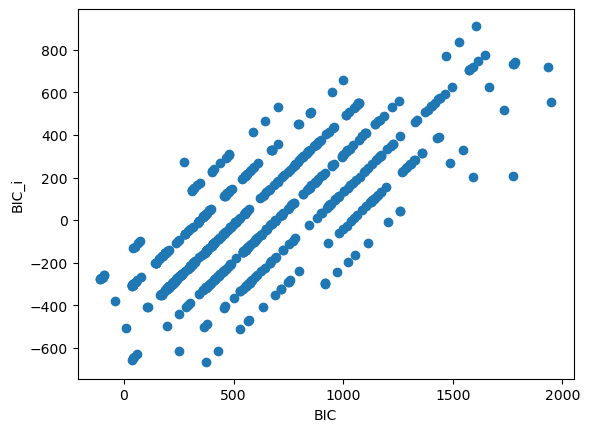

In [118]:
plt.scatter(t_eq['final_BIC'],t_eq['final_BIC_i'])
plt.xlabel('BIC')
plt.ylabel('BIC_i')

In [80]:
t_eq

,complexity,loss,score,equation,sympy_format,lambda_format,number_constants,variables,number_variables,unique_number_variables,...,final_equation,logdet,sqrt_cov,final_loss,optimized_params,N_para,residual_array,ad_p_value_array,final_BIC,final_BIC_i
0,1,4.906695,0.000000,x48,x48,PySRFunction(X=>x48),0,{'x48'},1,1,...,x48,415.778965,[0.12030085 0.09983006 0.11329922 0.09226658 0...,265.844161,"{'x48': tensor([10.7761, 10.8864, 9.6116, 10....",96.0,[[-0.55875355 -0.71532739 -1.55247791 -0.89229...,[6.38297872e-06 6.38297872e-06 3.19148936e-06],702.000460,531.594415
1,15,0.088578,0.044147,((x12 - (exp(log10(exp(0.04766298070500929) / ...,x12 - (1.048817124146649/(x19 + 0.047662980705...,PySRFunction(X=>x12 - (1.048817124146649/(x19 ...,3,"{'x19', 'x29', 'x12'}",3,3,...,x12 - 2.6642741626077204*log(x29) - -1.0560000...,1575.381156,[0.50257002 1.17312384 0.321639 0.53110829 0...,-617.546269,"{'p0': tensor(-0.0492, dtype=torch.float64), '...",287.0,[[ 5.55444949e-03 -6.09610566e-02 4.03585041e...,[6.38297872e-06 6.38297908e-06 1.89978983e-01 ...,686.379333,166.270868
2,16,0.088371,0.002337,((x12 - (exp(log10(exp(exp(-1.0423515630962228...,x12 - (exp(0.35262448748241617/x12)/x19)**(1/l...,PySRFunction(X=>x12 - (exp(0.35262448748241617...,2,"{'x19', 'x29', 'x12'}",4,3,...,x12 - log10(x29) - exp(log10(exp(-892.51911717...,1368.388460,[7.36200504e+07 1.96036663e-02 1.00660717e-01 ...,-482.355234,"{'p0': tensor(892.5191, dtype=torch.float64), ...",286.0,[[ 0.31158438 -0.35914801 0.09708903 0.52270...,[2.57224005e-02 2.46548450e-01 3.47535449e-03 ...,817.027073,298.615621
3,17,0.086897,0.016823,((x12 - (exp(log10(exp(x29 / x12) / (x19 + 0.0...,x12 - (exp(x29/x12)/(x19 + 0.04766298070500929...,PySRFunction(X=>x12 - (exp(x29/x12)/(x19 + 0.0...,2,"{'x29', 'x12', 'x19'}",5,3,...,x12 - log10(x29) - exp(log10(exp(x29/x12)/(x19...,1411.499468,[0.05564051 0.64520544 0.10268228 0.07198419 0...,-498.603762,"{'p0': tensor(1.4297, dtype=torch.float64), 'p...",286.0,[[ 3.14545899e-01 -2.91278609e-01 8.53778729e...,[9.23180377e-03 3.25853870e-01 7.87983026e-03 ...,800.778546,282.398113
4,19,0.086145,0.004346,((x12 - (exp(log10(exp(x29 / x12) / ((x19 - x1...,x12 - (exp(x29/x12)/(-x14 + x19 + 0.0476629807...,PySRFunction(X=>x12 - (exp(x29/x12)/(-x14 + x1...,2,"{'x29', 'x14', 'x12', 'x19'}",6,4,...,x12 - log10(x29) - exp(log10(exp(x29/x12)/(-x1...,1739.737296,[0.0592699 0.97218862 0.1028553 0.07229603 0...,-587.374376,"{'p0': tensor(1.4937, dtype=torch.float64), 'p...",381.0,[[ 3.35298116e-01 -2.71626209e-01 7.54519398e...,[9.67067020e-03 2.99490484e-01 6.98812005e-03 ...,1143.620936,450.851263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,13,0.015437,0.052914,((((x15 * 3.0860786087580303) - -2.72029684243...,3.0860786087580303*x15 + 2.835860812650755 - 2...,PySRFunction(X=>3.0860786087580303*x15 + 2.835...,3,"{'x26', 'x15', 'x29'}",4,3,...,2.0409876991822156*x15 + 5.945015722019364 - 2...,1906.743277,[0.24733026 0.86698112 0.31301173 0.00659239 0...,-1101.787915,"{'p0': tensor(2.9610, dtype=torch.float64), 'p...",286.0,[[-4.48430785e-02 2.60713370e-02 1.36708044e...,[6.38297872e-06 6.38297872e-06 6.38297872e-06 ...,197.594392,-320.485297
787,11,0.013242,0.190891,((x15 * (3.4412858435521843 - (x29 / (x26 + 0....,x15*(-x29/(x26 + 0.012180693250749317) + 3.441...,PySRFunction(X=>x15*(-x29/(x26 + 0.01218069325...,3,"{'x26', 'x15', 'x29'}",3,3,...,x15*(-x29/(x26 + -0.5147709497403206) + 3.1007...,1891.737926,[0.12608357 0.54486175 0.21843354 0.00659031 0...,-1098.963259,"{'p0': tensor(0.5148, dtype=torch.float64), 'p...",286.0,[[-7.23121635e-02 3.03752162e-02 1.66972166e...,[6.38297872e-06 6.38297872e-06 6.38297890e-06 ...,200.419049,-317.668541
788,25,0.012863,0.002140,((((x15 * (3.4412858435521843 - (x29 / x26))) ...,x15*(3.4412858435521843 - x29/x26) + log(exp(1...,PySRFunction(X=>x15*(3.4412858435521843 - x29/...,6,"{'x0', 'x26', 'x15', 'x29'}",5,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,22,0.011836,0

In [41]:
t_eq.iloc[3]

complexity                                                                17
loss                                                                0.086897
score                                                               0.016823
equation                   ((x12 - (exp(log10(exp(x29 / x12) / (x19 + 0.0...
sympy_format               x12 - (exp(x29/x12)/(x19 + 0.04766298070500929...
lambda_format              PySRFunction(X=>x12 - (exp(x29/x12)/(x19 + 0.0...
number_constants                                                           2
variables                                              {'x29', 'x12', 'x19'}
number_variables                                                           5
unique_number_variables                                                    3
evolutions                                                                 0
iterations                                                                 0
fitting_format             x12 - log10(x29) - exp(log10(exp(x29/x12)/(x19...

In [81]:
# sort by BIC_i from lowest to highest
t_eq.sort_values(by='final_BIC_i',inplace=True)

In [103]:
t_eq.iloc[0]['final_equation']

'x15*(3.4905981833436885 - x29/x26) + 2.0698447703602105 - (x10 + x47 + 0.024824774270344043)/x52**x19'

In [99]:
low_scatter_para[29]

'logRho_soi_approx_new'

In [114]:
string2array(t_eq.iloc[10]['ad_p_value_array'])

array([[5.57496915e-04, 6.38297872e-06, 3.87896195e-04, 3.87896195e-04,
        6.54516621e-06, 1.27659574e-06]])

In [87]:
t_eq.iloc[0]

complexity                                                                21
loss                                                                0.010904
score                                                               0.005629
equation                   (((x15 * (3.421570828337736 - (x29 / x26))) + ...
sympy_format               x15*(3.421570828337736 - x29/x26) + 2.26253375...
lambda_format              PySRFunction(X=>x15*(3.421570828337736 - x29/x...
number_constants                                                           4
variables                  {'x26', 'x15', 'x10', 'x19', 'x52', 'x47', 'x29'}
number_variables                                                           7
unique_number_variables                                                    7
evolutions                                                                 3
iterations                                                              3336
fitting_format             x15*(p[1] - x29/x26) + p[0] - (x10 + x47 + p[2...

In [48]:
eval(t_eq.iloc[319]['optimized_params'], {'tensor': torch.tensor,'torch': torch})

{'p0': tensor(2.7396, dtype=torch.float64),
 'p1': tensor(4.8135, dtype=torch.float64),
 'x15': tensor([2.4719, 2.5147, 1.5747, 2.3742, 2.2954, 2.2928, 2.1793, 2.3900, 2.3481,
         2.4693, 2.2548, 2.5205, 2.4256, 2.5224, 2.1489, 2.1869, 2.2817, 2.4938,
         2.4154, 2.3154, 2.1346, 2.3065, 2.1579, 2.3739, 2.0174, 2.3308, 2.3461,
         2.2892, 2.3347, 2.4902, 2.3915, 2.4197, 2.2398, 2.4724, 2.4660, 2.0471,
         2.3811, 2.2587, 2.1089, 2.4434, 2.2398, 2.0674, 2.2344, 2.4504, 2.2517,
         2.5097, 2.3522, 2.3984, 2.1936, 2.0499, 2.1482, 2.3575, 2.5194, 2.2181,
         2.0069, 2.1484, 2.5947, 2.3252, 2.4004, 2.0252, 2.5374, 2.2618, 2.3731,
         2.3616, 2.3755, 2.5850, 2.1062, 1.8405, 2.5013, 2.4615, 2.0925, 2.1879,
         1.9960, 2.2903, 2.3073, 2.0294, 2.2833, 2.1391, 2.3652, 2.1807, 2.2150,
         2.1021, 2.0734, 2.0975, 1.9799, 2.1251, 1.9779, 2.0005, 2.2150, 2.3537,
         2.2842, 2.0297, 1.9782, 2.0774], dtype=torch.float64),
 'intrinsic_scatter': tensor(0.

In [70]:
str_array=t_eq.iloc[319]['residual_array']

def string2array(str_array):
    # Clean the string and split into rows
    cleaned = re.sub(r'\s+', ' ', str_array)  # Remove extra whitespace
    rows = re.split(r'\s*\]\s*,\s*\[|\s*\]\s*\[\s*', cleaned.strip('[]'))

    # Remove empty strings from rows (if any)
    rows = [row for row in rows if row]

    # Parse elements and infer shape
    elements = []
    for row in rows:
        elements.extend([float(x) for x in row.split()])

    n_rows = len(rows)
    n_cols = len(elements) // n_rows  # Integer division

    # Reshape into NumPy array
    array = np.array(elements).reshape(n_rows, n_cols)
    return array

residual_array=string2array(str_array)

In [78]:
string2array(t_eq.iloc[100]['residual_array'])

array([[-4.89372768e-02,  9.05391260e-03,  2.25590383e-01,
        -6.70544133e-02,  3.87750260e-02, -9.54285228e-03,
         2.07997694e-02, -1.45303304e-04,  5.89166860e-02,
         1.55979637e-02,  9.43608722e-02,  3.71006362e-03,
        -2.66398101e-02,  5.29164686e-04, -4.32174513e-02,
        -3.89983693e-01, -3.62607748e-02, -6.25717044e-03,
        -1.00919960e-01,  1.44079153e-01,  1.95248408e-01,
         3.16018195e-02, -1.75963997e-01, -1.12947205e-02,
         1.39705904e-02, -1.58212619e-02,  7.82783573e-02,
         1.04639844e-01,  8.17529578e-02, -1.29366091e-01,
        -3.61351467e-02, -4.86172708e-01, -1.66583648e-02,
         1.48967965e-01,  1.22706799e-01,  9.64967156e-02,
        -7.42318170e-02,  3.40125138e-04,  2.84596521e-02,
        -1.79874935e-02,  2.74082148e-02,  5.60089283e-02,
         2.24479705e-02, -1.02789052e-02, -9.21792927e-02,
        -1.41608995e-02,  7.48714893e-03, -1.51550436e-03,
         1.74180706e-01,  2.62485023e-02,  1.13069518e-0